In [3]:
import pandas as pd
import numpy as np
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import shap
import joblib

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder, RobustScaler, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from collections import Counter
from numbers import Number

# **EDA**

In [4]:
df = pd.read_csv("data_D.csv")
df.head(3)

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x20c27,CUS_0xf64,June,NaN,32,478-73-8323,Doctor,56125.5,4875.125000,...,Standard,370.22,32.014182,28 Years and 10 Months,Yes,81.822857,182.06551022025016,High_spent_Medium_value_payments,473.62413320457887,Standard
1,1,0xc518,CUS_0x697f,March,Philh,39,367-66-5050,Entrepreneur,62148.0,NaN,...,Bad,2373.61,33.951720,16 Years and 6 Months,Yes,258.848861,195.3722153038279,High_spent_Small_value_payments,300.6789235920986,Poor
2,2,0x22663,CUS_0x7846,February,Paramadithak,45,282-14-9365,Accountant,88380.16,7471.013333,...,_,124.29,41.016763,NaN,Yes,129.723699,180.79874191787297,High_spent_Medium_value_payments,686.5788927990964,Standard


In [5]:
df.drop(columns=['Unnamed: 0', 'ID', 'Customer_ID', 'Name', 'SSN'], inplace=True)

In [6]:
df.shape

(25000, 24)

In [7]:
df.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,21173.000000,25000.000000,25000.000000,25000.000000,25000.000000,24503.000000,25000.000000,25000.000000
mean,4168.307097,16.865000,23.311840,70.358920,21.065360,26.939762,32.273187,1440.039648
std,3170.867622,114.767426,133.618787,458.469762,14.885855,189.253774,5.114177,8514.909613
min,303.645417,-1.000000,0.000000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.265833,4.000000,4.000000,8.000000,10.000000,3.000000,28.059564,29.912485
50%,3080.353333,6.000000,5.000000,13.000000,18.000000,6.000000,32.331522,68.781136
75%,5927.527500,8.000000,7.000000,20.000000,28.000000,9.000000,36.475246,160.180388
max,15204.633333,1794.000000,1499.000000,5789.000000,67.000000,2553.000000,49.564519,82122.000000


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  object 
 1   Age                       25000 non-null  object 
 2   Occupation                25000 non-null  object 
 3   Annual_Income             25000 non-null  object 
 4   Monthly_Inhand_Salary     21173 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  int64  
 6   Num_Credit_Card           25000 non-null  int64  
 7   Interest_Rate             25000 non-null  int64  
 8   Num_of_Loan               25000 non-null  object 
 9   Type_of_Loan              22120 non-null  object 
 10  Delay_from_due_date       25000 non-null  int64  
 11  Num_of_Delayed_Payment    23256 non-null  object 
 12  Changed_Credit_Limit      25000 non-null  object 
 13  Num_Credit_Inquiries      24503 non-null  float64
 14  Credit

Several columns that should be numeric are stored as object such as 'Age', 'Annual_Income', 'Outstanding_Debt', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Monthly_Balance'

In [9]:
for col in ['Age', 'Annual_Income', 'Outstanding_Debt', 'Num_of_Loan',
            'Num_of_Delayed_Payment', 'Monthly_Balance']:
    df[col] = pd.to_numeric(df[col].astype(str).str.rstrip('_'), errors='coerce')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  object 
 1   Age                       25000 non-null  int64  
 2   Occupation                25000 non-null  object 
 3   Annual_Income             25000 non-null  float64
 4   Monthly_Inhand_Salary     21173 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  int64  
 6   Num_Credit_Card           25000 non-null  int64  
 7   Interest_Rate             25000 non-null  int64  
 8   Num_of_Loan               25000 non-null  int64  
 9   Type_of_Loan              22120 non-null  object 
 10  Delay_from_due_date       25000 non-null  int64  
 11  Num_of_Delayed_Payment    23256 non-null  float64
 12  Changed_Credit_Limit      25000 non-null  object 
 13  Num_Credit_Inquiries      24503 non-null  float64
 14  Credit

All columns now have correct data types

In [11]:
for columnName in df.columns:
    print(f"Kolom: {columnName}")
    print(df[columnName].unique())

Kolom: Month
['June' 'March' 'February' 'January' 'July' 'April' 'May' 'August']
Kolom: Age
[  32   39   45   18   28   30   37   25   21   40   42   52   22   43
   34   20   38   51   17   27   19   46   33   56   26   53   15   24
   36   31   29   14   23   54   47   49   41   35   16   44 1820   50
   48   55 3651 5975 -500 7986 6424 5123 2341 6799 8567 2175 2037 5995
 7323 7851 2977 2474 7553  359 1515 1695 2084 7886 7806 1657 4906 1651
  306 1220 2733 7459 4270  328 7776  940  774 5717 7223 1787 4580 3665
 1176 6777 5222  112 2756  581 6091 5018 2048 2209 8561 7131 1664 5788
 2821 6074 3441 6378  372 3966 7723 5101 4501 6520  252 6471 6925 3891
 1033 6226  828 8608 4655 3274  488 6704  335 2382 5465 4862 8043 7377
 3167 2799 1322 1451 2563 1752 6796 4946 4177 1443 3607 4202 2578 7235
 3988 3193 8015 3159 8035  292 4194 2097 7508 8127 3795 6835 4414 5615
 6770 7962 5233  234 8286 5532 7710 4188 4958 4894 4416 7524 8069 2276
 6015 7879  333 2090 4271 3910 5981  637 6364 2369 1294 

* Age: Found trailing underscores (e.g., '52_'), negative numbers (-500), and unrealistic thousands values (e.g., 1820, 3651), which are impossible for human age.
* Num_Bank_Accounts & Num_Credit_Card: Found extreme outliers in the thousands (e.g., 1599, 1127) and invalid negative values (-1), which are financially unrealistic.
* Interest_Rate: Contains impossible interest rates reaching thousands of percent (e.g., 3480, 5651).
* Num_of_Loan & Num_of_Delayed_Payment: Contaminated with extreme thousands values and unwanted text/symbols (e.g., trailing underscores).
* Payment_Behaviour: Contains special character noise ('!@9#%8') instead of proper categorical descriptions.

### **Handling Weird Value**

In [12]:
# Amount_invested_monthly has '__10000__'
df['Amount_invested_monthly'] = pd.to_numeric(
    df['Amount_invested_monthly'].astype(str).str.replace('_', '', regex=False), errors='coerce')

In [13]:
# Changed_Credit_Limit has '_'
df['Changed_Credit_Limit'] = pd.to_numeric(
    df['Changed_Credit_Limit'].replace('_', np.nan), errors='coerce')

In [14]:
# Monthly_Balance also has underscores
df['Monthly_Balance'] = pd.to_numeric(
    df['Monthly_Balance'].astype(str).str.replace('_', '', regex=False), errors='coerce')

In [15]:
# check placeholder values in categorical columns
print(f"Occupation '_______': {(df['Occupation'] == '_______').sum()}")
print(f"Credit_Mix '_': {(df['Credit_Mix'] == '_').sum()}")
print(f"Payment_of_Min_Amount 'NM': {(df['Payment_of_Min_Amount'] == 'NM').sum()}")
print(f"Payment_Behaviour '!@9#%8': {(df['Payment_Behaviour'] == '!@9#%8').sum()}")

Occupation '_______': 1735
Credit_Mix '_': 5031
Payment_of_Min_Amount 'NM': 2978
Payment_Behaviour '!@9#%8': 1894


In [16]:
# replace all placeholders with nan
df['Occupation'] = df['Occupation'].replace('_______', np.nan)
df['Credit_Mix'] = df['Credit_Mix'].replace('_', np.nan)
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace('NM', np.nan)
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', np.nan)

In [17]:
print(f"Occupation '_______': {(df['Occupation'] == '_______').sum()}")
print(f"Credit_Mix '_': {(df['Credit_Mix'] == '_').sum()}")
print(f"Payment_of_Min_Amount 'NM': {(df['Payment_of_Min_Amount'] == 'NM').sum()}")
print(f"Payment_Behaviour '!@9#%8': {(df['Payment_Behaviour'] == '!@9#%8').sum()}")

Occupation '_______': 0
Credit_Mix '_': 0
Payment_of_Min_Amount 'NM': 0
Payment_Behaviour '!@9#%8': 0


In [18]:
# check for values that are most likely data entry errors
print(f"Age range: {df['Age'].min()} to {df['Age'].max()}")
print(f"Interest_Rate max: {df['Interest_Rate'].max()}")
print(f"Num_of_Loan min: {df['Num_of_Loan'].min()}")
print(f"Num_Bank_Accounts min: {df['Num_Bank_Accounts'].min()}")
print(f"Monthly_Balance min: {df['Monthly_Balance'].min():.2e}")

Age range: -500 to 8669
Interest_Rate max: 5789
Num_of_Loan min: -100
Num_Bank_Accounts min: -1
Monthly_Balance min: 6.00e-01


In [19]:
# age -500 and 8669 are clearly data entry errors, valid range is 14-100
df.loc[(df['Age'] < 14) | (df['Age'] > 100), 'Age'] = np.nan

In [20]:
# interest_rate max 5789 is definitely an error, normal range is 1-40%
df.loc[df['Interest_Rate'] > 40, 'Interest_Rate'] = np.nan

In [21]:
# num_of_loan -100 is a sentinel value, and values like 1485 are didn't make sense
df.loc[(df['Num_of_Loan'] == -100) | (df['Num_of_Loan'] > 10), 'Num_of_Loan'] = np.nan

In [22]:
# num_bank_accounts can't have negative or 1000+ accounts
df.loc[(df['Num_Bank_Accounts'] < 0) | (df['Num_Bank_Accounts'] > 20), 'Num_Bank_Accounts'] = np.nan

In [23]:
# num_credit_card values like 1499 are definitely input errors
df.loc[df['Num_Credit_Card'] > 15, 'Num_Credit_Card'] = np.nan

In [24]:
# num_of_delayed_payment values like 4340 are incorrect
df.loc[df['Num_of_Delayed_Payment'] > 30, 'Num_of_Delayed_Payment'] = np.nan

In [25]:
# num_credit_inquiries values like 2553 are didn't make sense
df.loc[df['Num_Credit_Inquiries'] > 20, 'Num_Credit_Inquiries'] = np.nan

In [26]:
# total_emi_per_month values like 82122 also didn't make sense
df.loc[df['Total_EMI_per_month'] > 5000, 'Total_EMI_per_month'] = np.nan

In [27]:
# monthly_balance values like 6.00e-01 are clearly input errors
df.loc[df['Monthly_Balance'] < -10000, 'Monthly_Balance'] = np.nan

# **Feature Engineering**

In [28]:
# credit_history_age is a string like "28 Years and 10 Months"
# convert to total months
def parseHistory(val):
    if pd.isna(val): return np.nan
    try:
        parts = str(val).split(' ')
        return int(parts[0]) * 12 + int(parts[3])
    except:
        return np.nan
df['Credit_History_Months'] = df['Credit_History_Age'].apply(parseHistory)
df.drop(columns=['Credit_History_Age'], inplace=True)

In [29]:
# type_of_loan is a comma-separated string, convert to count
df['Loan_Type_Count'] = df['Type_of_Loan'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) else 0)
df.drop(columns=['Type_of_Loan'], inplace=True)

In [30]:
df.head(3)

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Credit_History_Months,Loan_Type_Count
0,June,32.0,Doctor,56125.50,4875.125000,8.0,3.0,18.0,2.0,30,...,370.22,32.014182,Yes,81.822857,182.065510,High_spent_Medium_value_payments,473.624133,Standard,346.0,2
1,March,39.0,Entrepreneur,62148.00,NaN,9.0,7.0,24.0,5.0,56,...,2373.61,33.951720,Yes,258.848861,195.372215,High_spent_Small_value_payments,300.678924,Poor,198.0,5
2,February,45.0,Accountant,88380.16,7471.013333,7.0,7.0,19.0,3.0,11,...,124.29,41.016763,Yes,129.723699,180.798742,High_spent_Medium_value_payments,686.578893,Standard,NaN,3


## **Handling Missing Values**

In [31]:
df.isnull().sum()

,0
Month,0
Age,690
Occupation,1735
Annual_Income,0
Monthly_Inhand_Salary,3827
Num_Bank_Accounts,337
Num_Credit_Card,581
Interest_Rate,497
Num_of_Loan,1046
Delay_from_due_date,0


There are  missing values across multiple column and dropping all rows with any NaN would lose too much data, so we impute median for numeric because the data distribustion quite skewed and mode for categorical

In [32]:
df.duplicated().sum()

np.int64(0)

There seem to be a few missing values in Name, Monthly_Inhand_Salary, Type_of_Loan, Num_of_Delayed_Payment, Num_Credit_Inquiries, Credit_History_Age, Amount_invested_monthly, and Monthly_Balance column. There is no duplicate values

In [33]:
# impute numeric columns with median
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

In [34]:
# impute categorical columns with mode
for col in df.select_dtypes(include=['object']).columns:
    if col != 'Credit_Score':
        df[col].fillna(df[col].mode()[0], inplace=True)

In [35]:
print(df.isnull().sum())

Month                       0
Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
Credit_History_Months       0
Loan_Type_Count             0
dtype: int64


## **Checking Outlier**

In [36]:
numCol = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in numCol:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    nOutliers = ((s < lo) | (s > hi)).sum()
    if nOutliers > 0:
        print(f"{col}: {nOutliers} outliers ({nOutliers/len(s)*100:.1f}%)")

Age: 1 outliers (0.0%)
Annual_Income: 699 outliers (2.8%)
Monthly_Inhand_Salary: 1171 outliers (4.7%)
Num_Credit_Card: 1 outliers (0.0%)
Delay_from_due_date: 1001 outliers (4.0%)
Changed_Credit_Limit: 319 outliers (1.3%)
Num_Credit_Inquiries: 191 outliers (0.8%)
Outstanding_Debt: 1357 outliers (5.4%)
Credit_Utilization_Ratio: 2 outliers (0.0%)
Total_EMI_per_month: 1382 outliers (5.5%)
Amount_invested_monthly: 2738 outliers (11.0%)
Monthly_Balance: 2059 outliers (8.2%)


There are still outliers in several columns but these are plausible extreme values rather than data errors (e.g. someone with many bank accounts or high EMI). Tree based models are robust to outliers so we keep them

In [37]:
print(df.info())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  object 
 1   Age                       25000 non-null  float64
 2   Occupation                25000 non-null  object 
 3   Annual_Income             25000 non-null  float64
 4   Monthly_Inhand_Salary     25000 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  float64
 6   Num_Credit_Card           25000 non-null  float64
 7   Interest_Rate             25000 non-null  float64
 8   Num_of_Loan               25000 non-null  float64
 9   Delay_from_due_date       25000 non-null  int64  
 10  Num_of_Delayed_Payment    25000 non-null  float64
 11  Changed_Credit_Limit      25000 non-null  float64
 12  Num_Credit_Inquiries      25000 non-null  float64
 13  Credit_Mix                25000 non-null  object 
 14  Outsta

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_History_Months,Loan_Type_Count
count,25000.000000,2.500000e+04,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,33.461920,1.666418e+05,4001.763135,5.371400,5.520360,14.47696,3.498480,21.065360,13.327800,10.397069,5.741880,1426.928708,32.273187,109.533841,619.491638,402.189461,221.313160,3.521680
std,10.645211,1.352158e+06,2944.261114,2.575198,2.040273,8.68883,2.400714,14.885855,6.094948,6.732732,3.808632,1158.880154,5.114177,174.583895,2013.830997,213.180422,95.389778,2.450406
min,14.000000,7.005930e+03,303.645417,0.000000,0.000000,1.00000,0.000000,-5.000000,-3.000000,-6.440000,0.000000,0.230000,20.000000,0.000000,0.000000,0.599640,2.000000,0.000000
25%,25.000000,1.953645e+04,1799.734375,4.000000,4.000000,8.00000,2.000000,10.000000,9.000000,5.500000,3.000000,566.980000,28.059564,29.912485,76.351319,271.744621,154.000000,2.000000
50%,33.000000,3.740467e+04,3080.353333,5.000000,5.000000,13.00000,3.000000,18.000000,14.000000,9.380000,5.000000,1158.960000,32.331522,66.367918,133.934709,338.075288,220.000000,3.000000
75%,42.000000,7.241314e+04,5319.353333,7.000000,7.000000,20.00000,5.000000,28.000000,18.000000,14.710000,8.000000,1943.080000,36.475246,142.390919,252.391171,464.569610,293.000000,5.000000
max,100.000000,2.419806e+07,15204.633333,11.000000,15.000000,34.00000,9.000000,67.000000,28.000000,36.970000,17.000000,4998.070000,49.564519,4927.000000,10000.000000,1602.040519,404.000000,9.000000


## **Checking Distributions**

In [38]:
numCol = []
catCol = []
for col in df.drop(columns='Credit_Score').columns:
    if df[col].dtype in ['int64', 'float64']:
        numCol.append(col)
    else:
        catCol.append(col)
print(f"Numerical: {numCol}")
print(f"Categorical: {catCol}")

Numerical: ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Months', 'Loan_Type_Count']
Categorical: ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


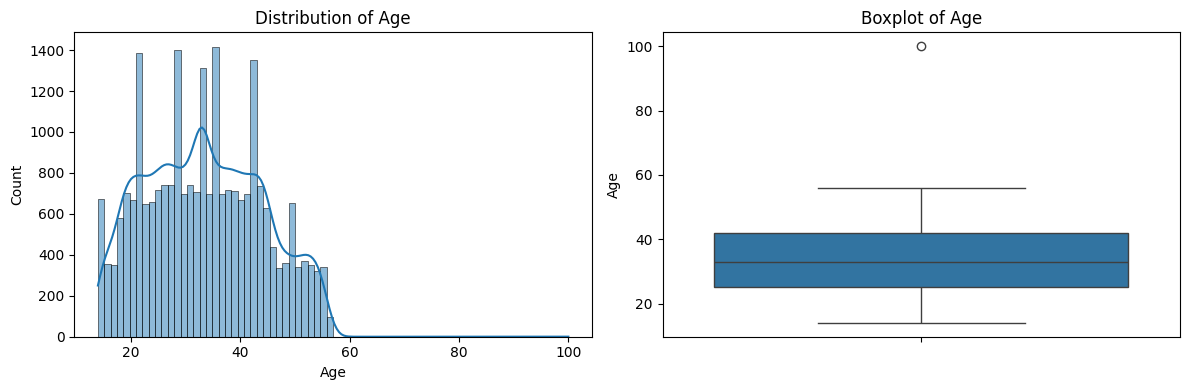

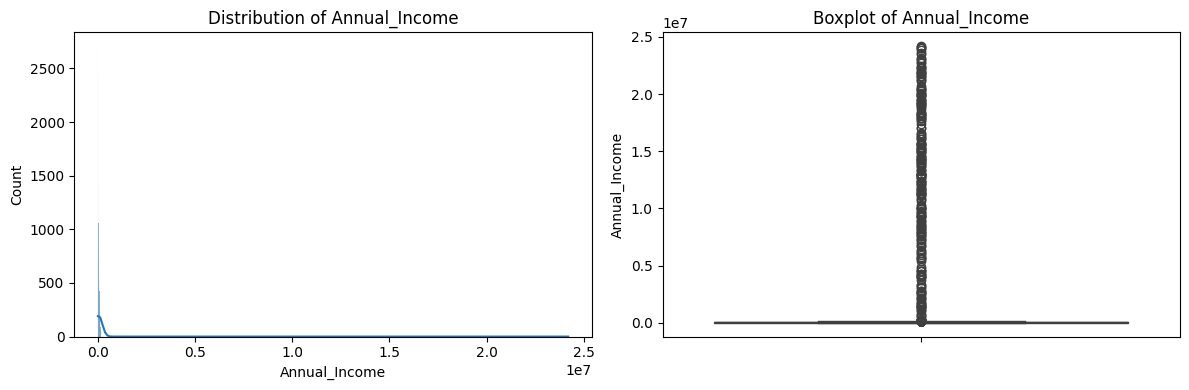

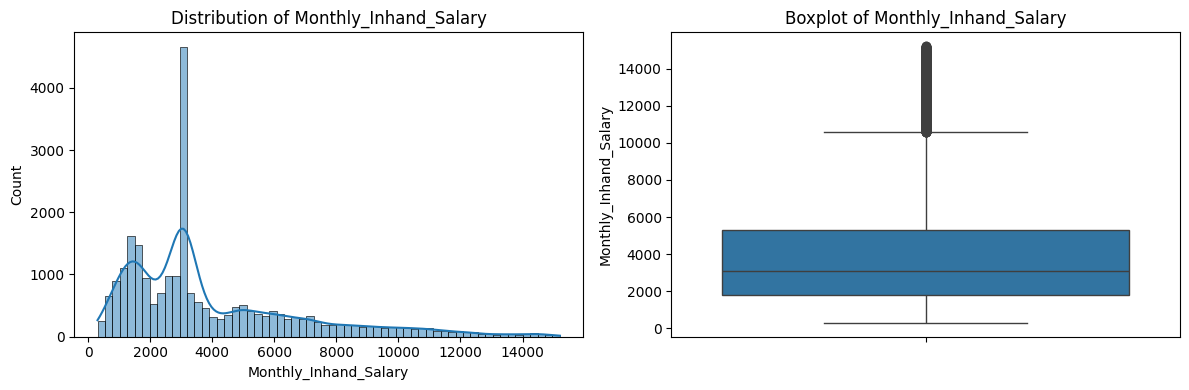

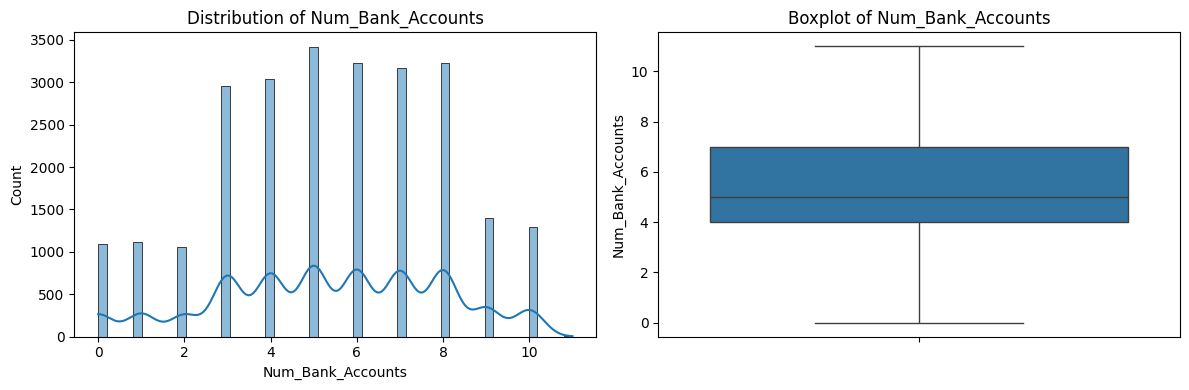

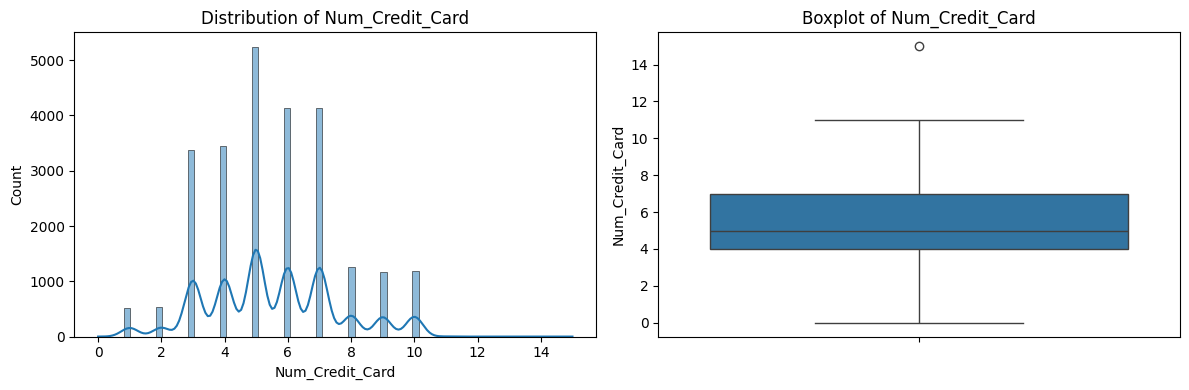

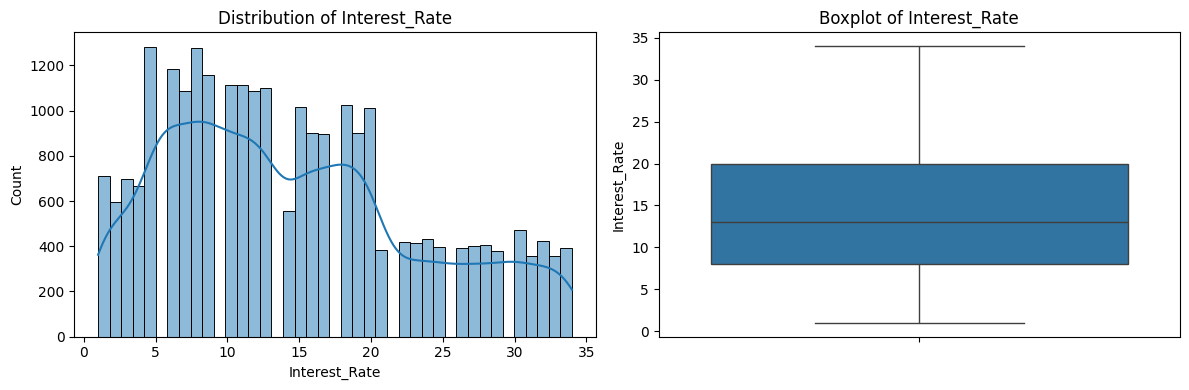

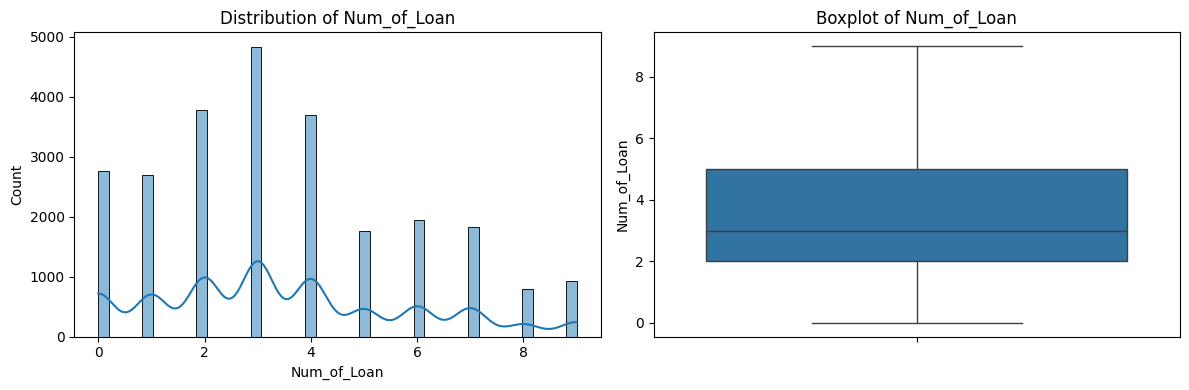

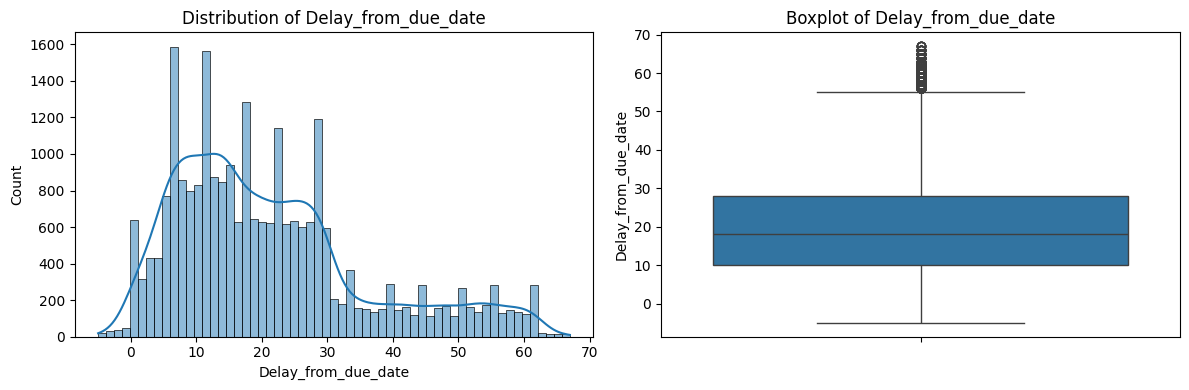

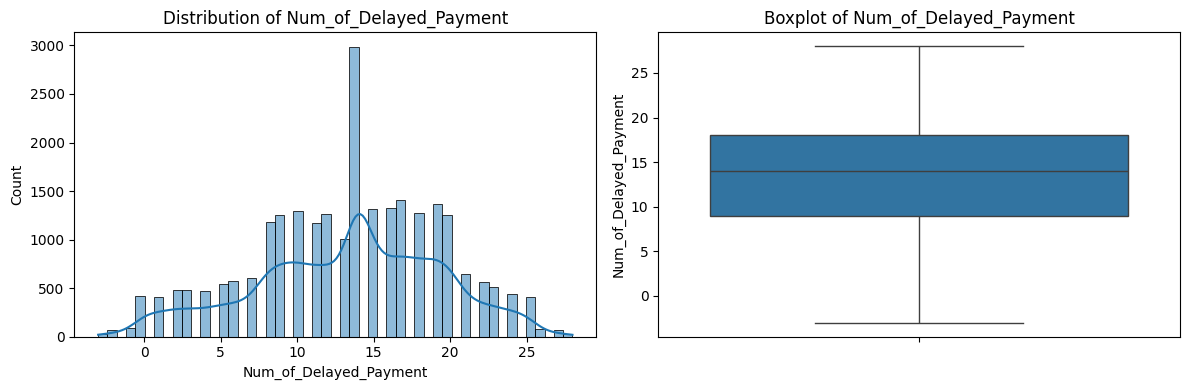

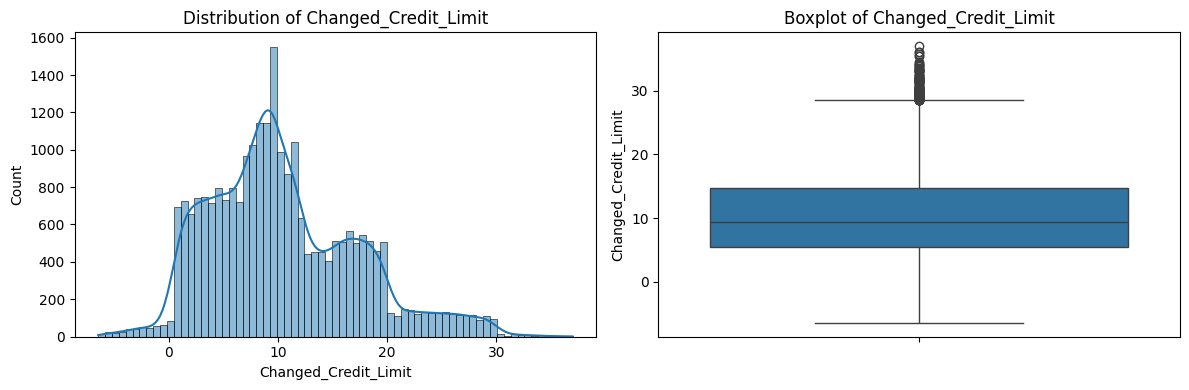

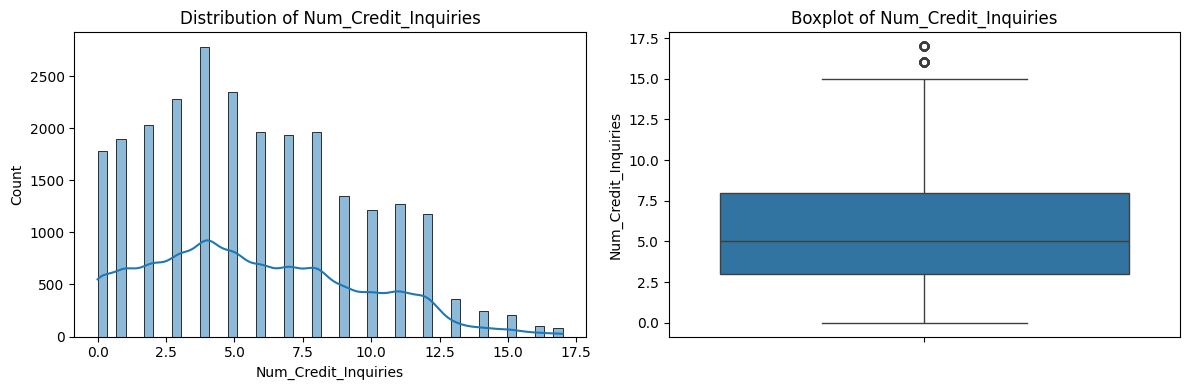

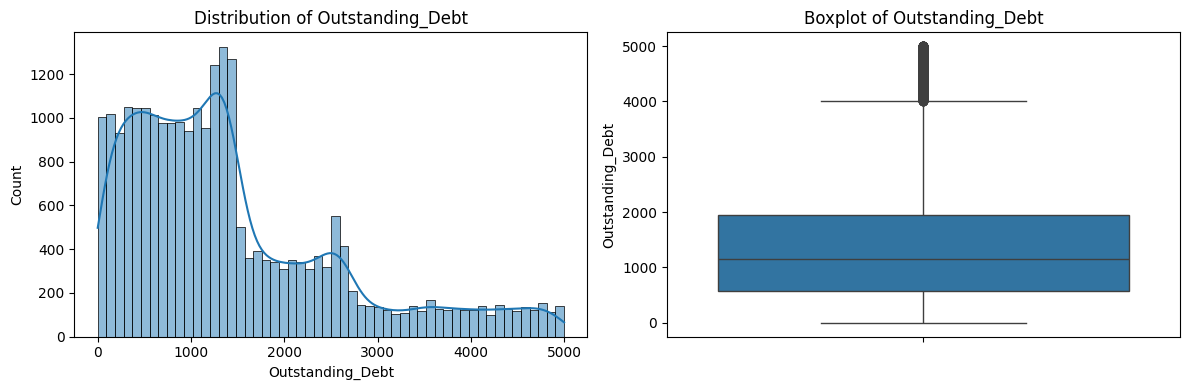

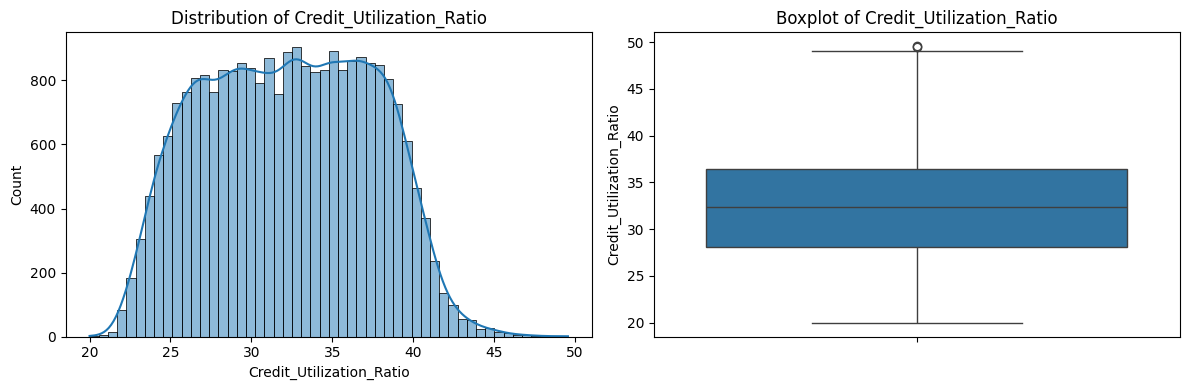

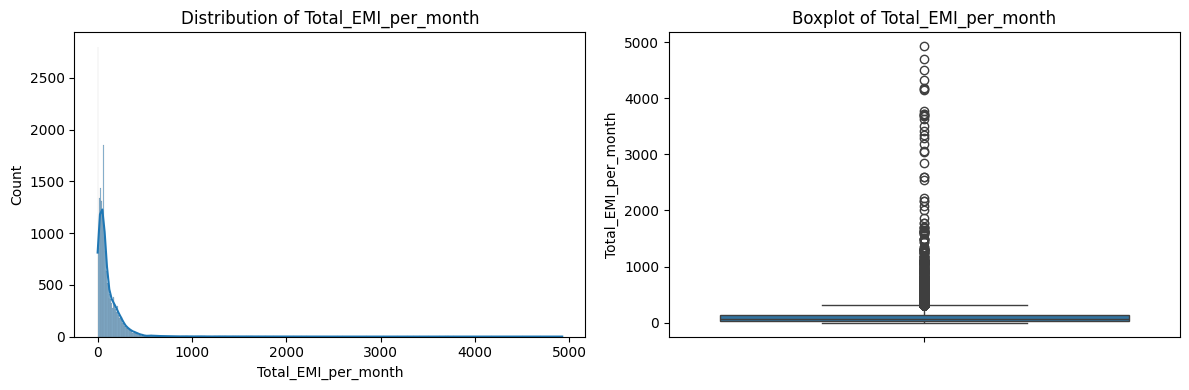

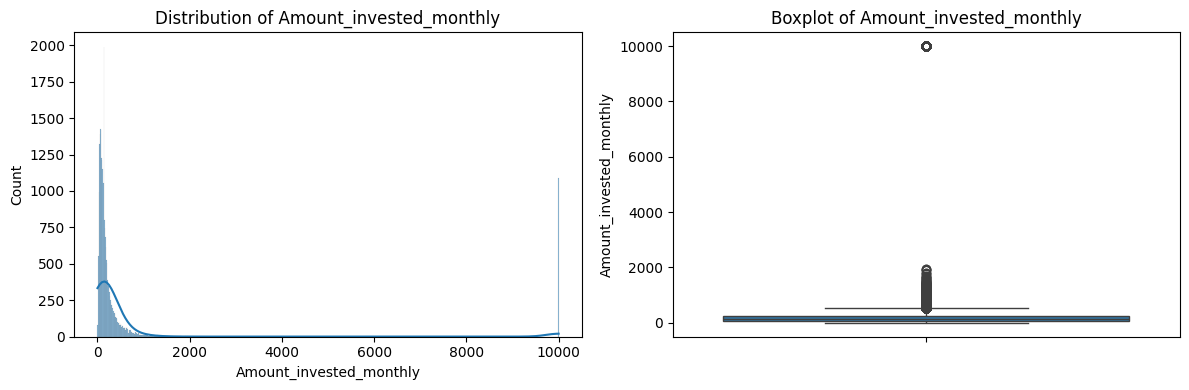

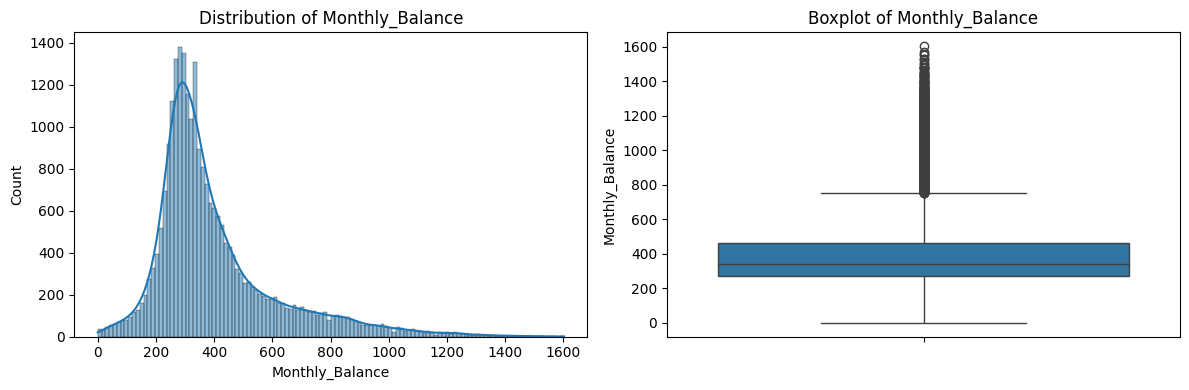

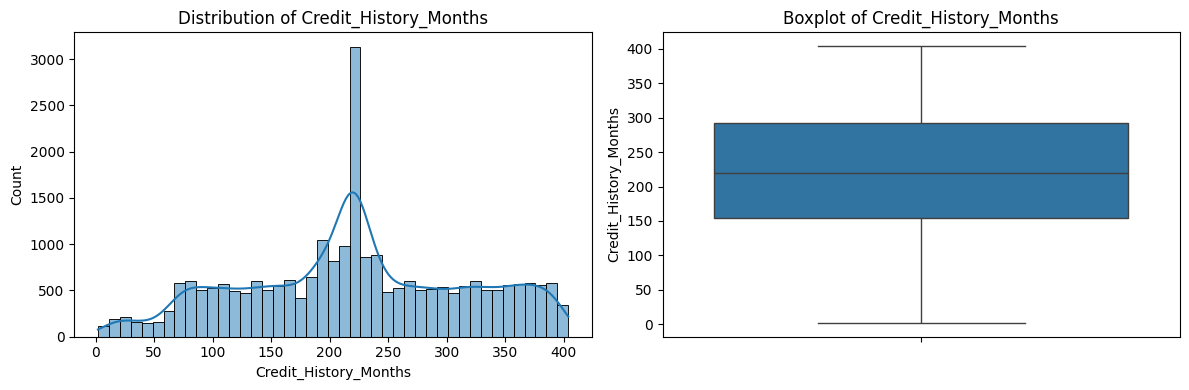

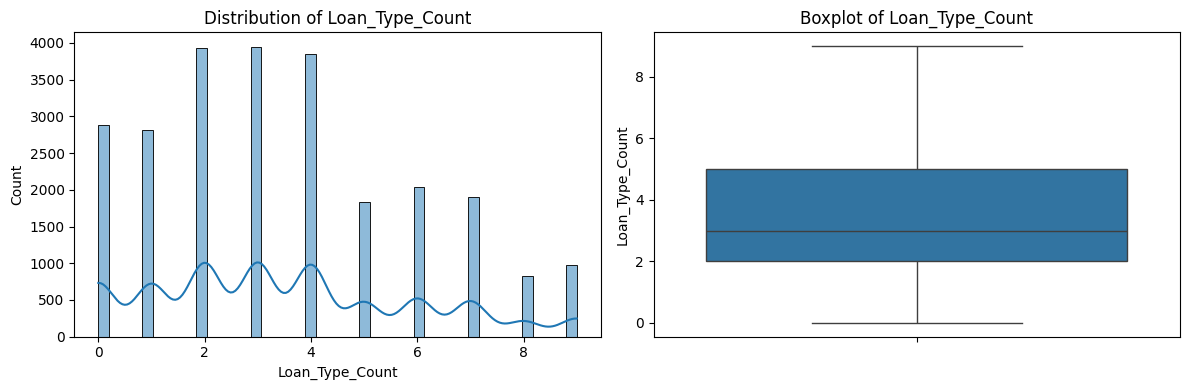

In [39]:
# numerical column distributions
for col in numCol:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')
    sns.boxplot(y=df[col].dropna(), ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

Several columns like Annual_Income, Total_EMI_per_month, and Amount_invested_monthly are right-skewed. But the value of the outlier make sense and it possible to happen so we decided to keep it

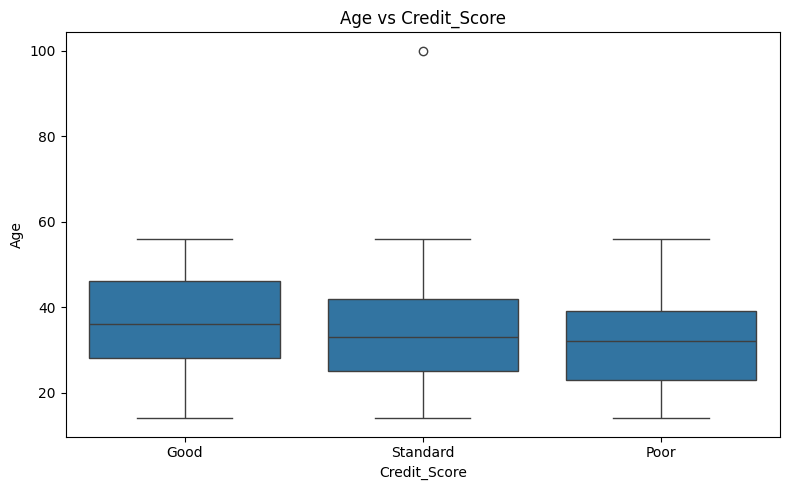

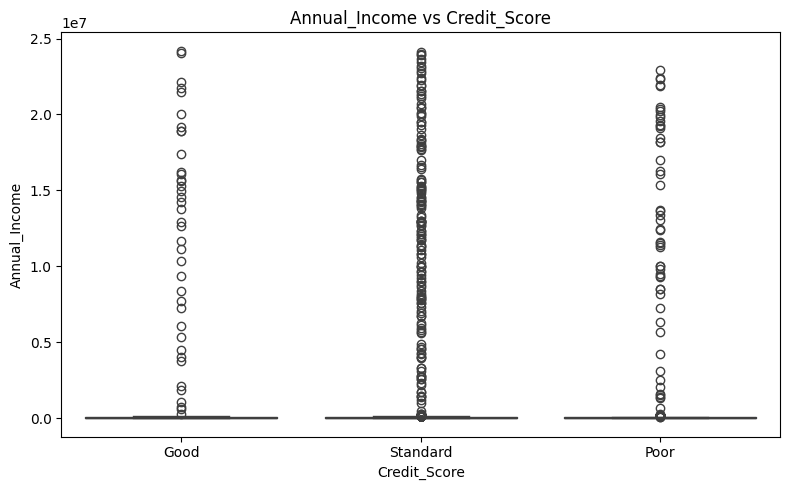

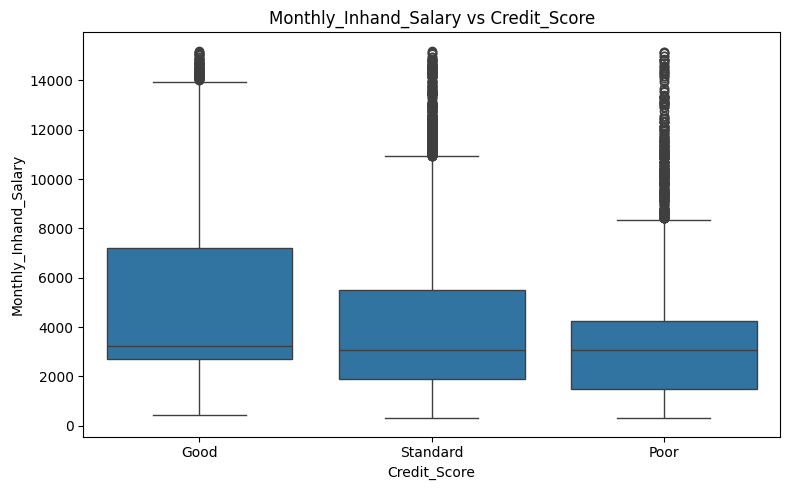

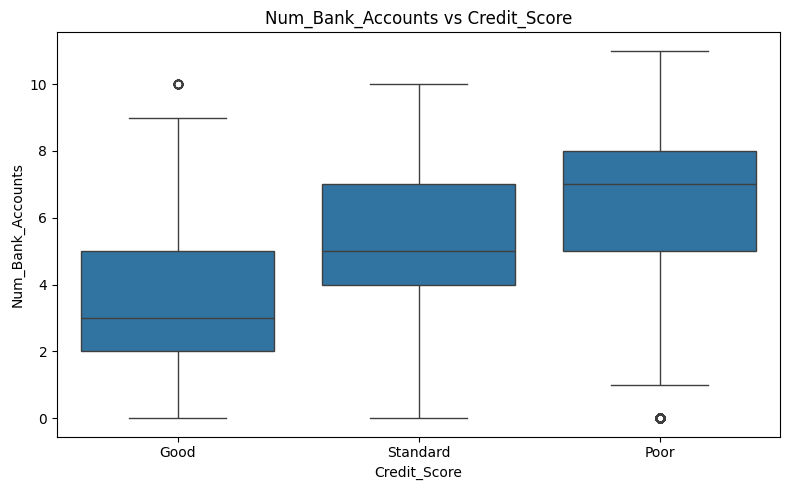

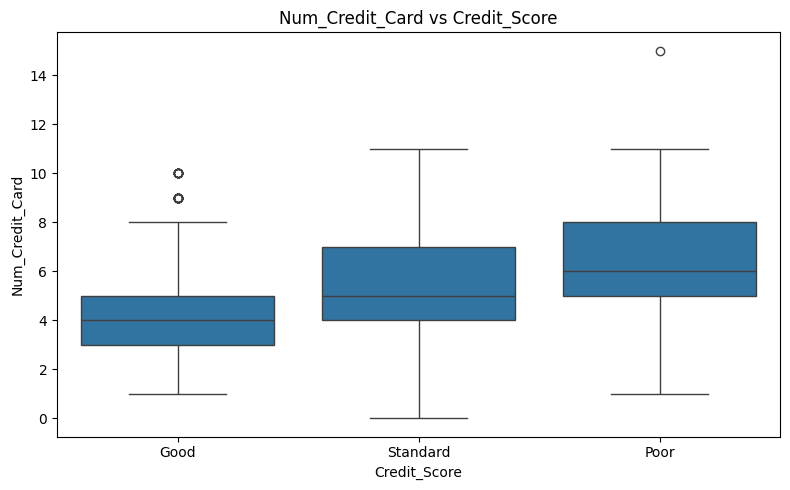

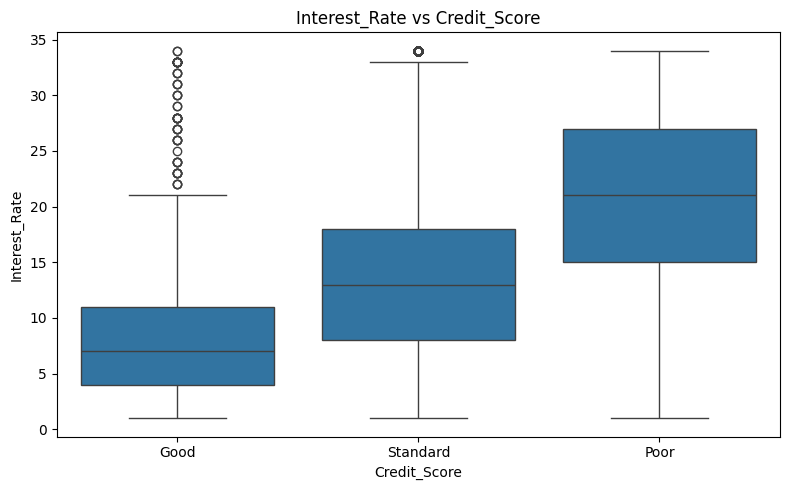

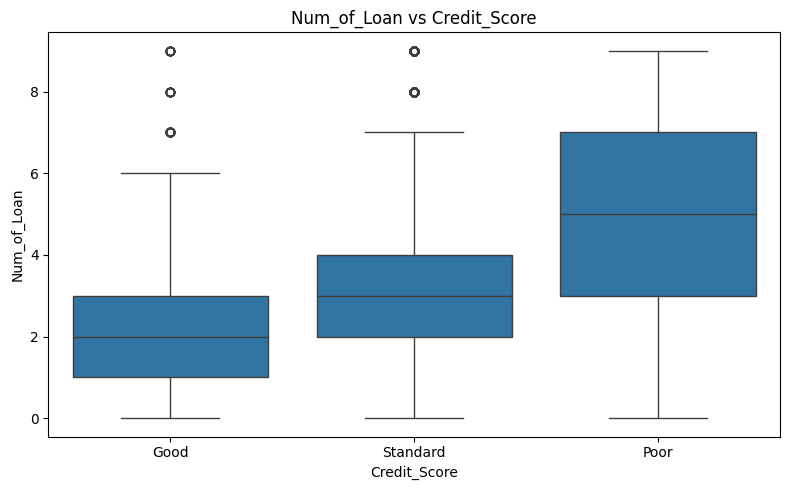

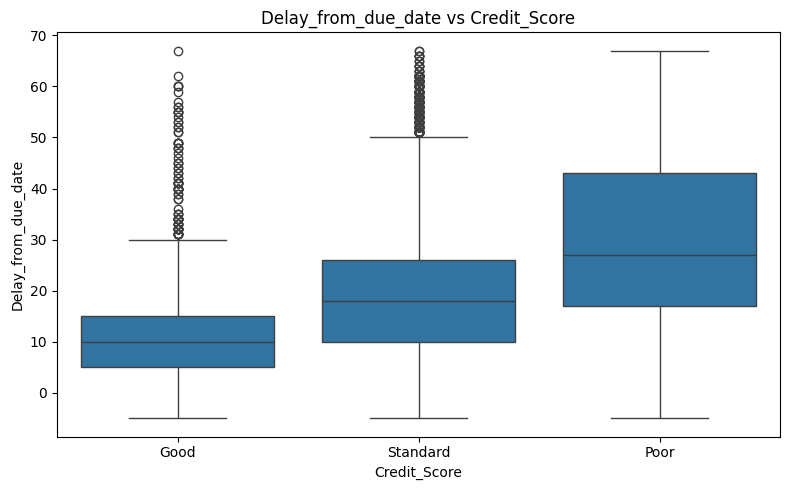

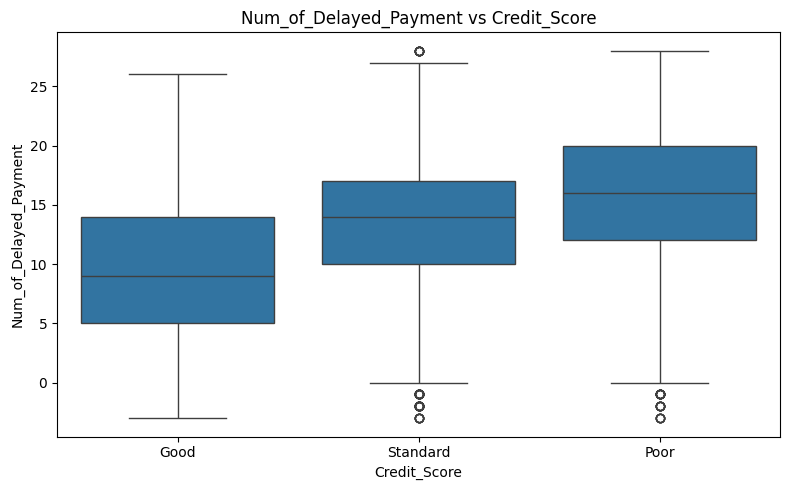

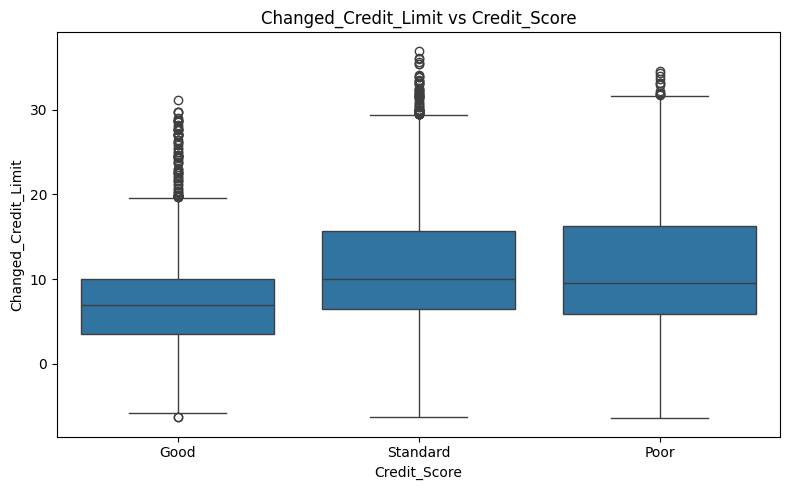

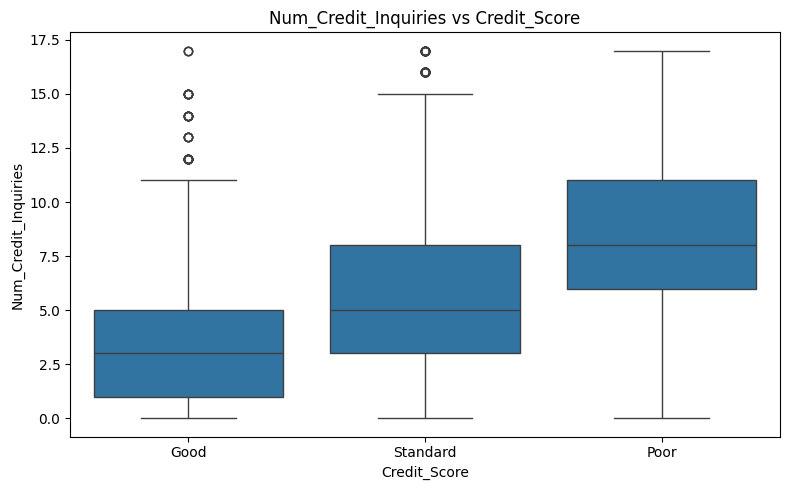

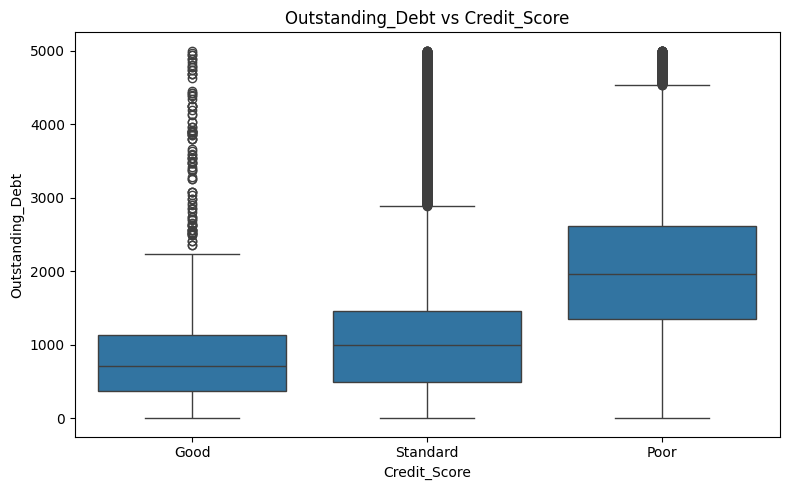

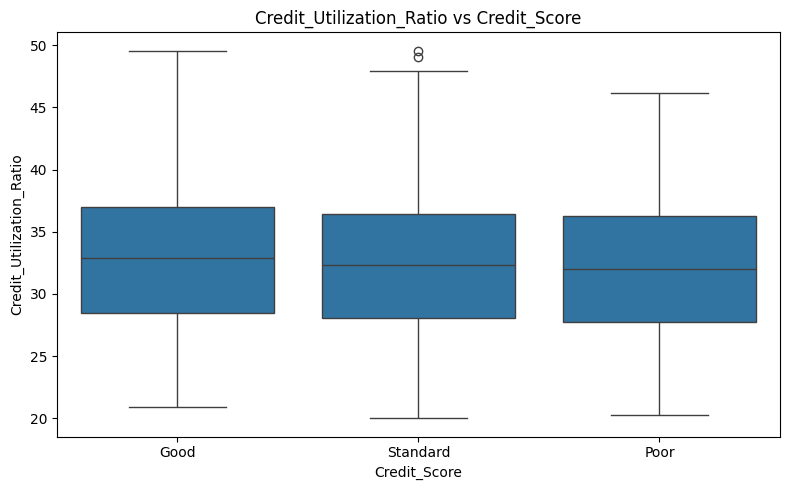

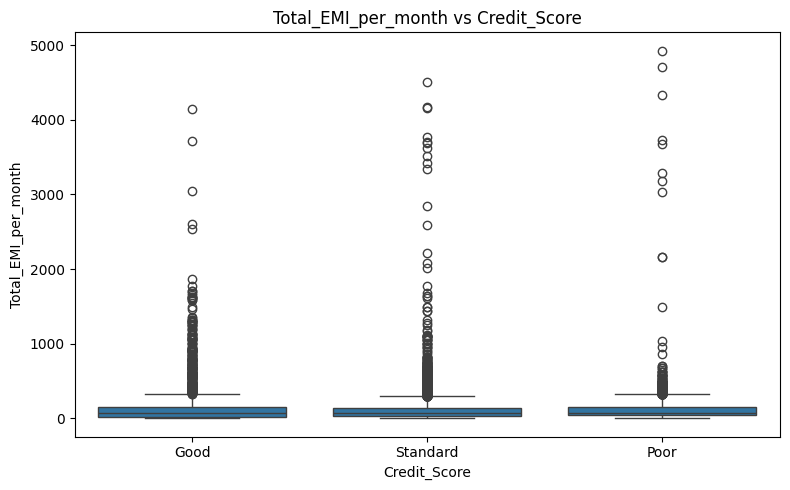

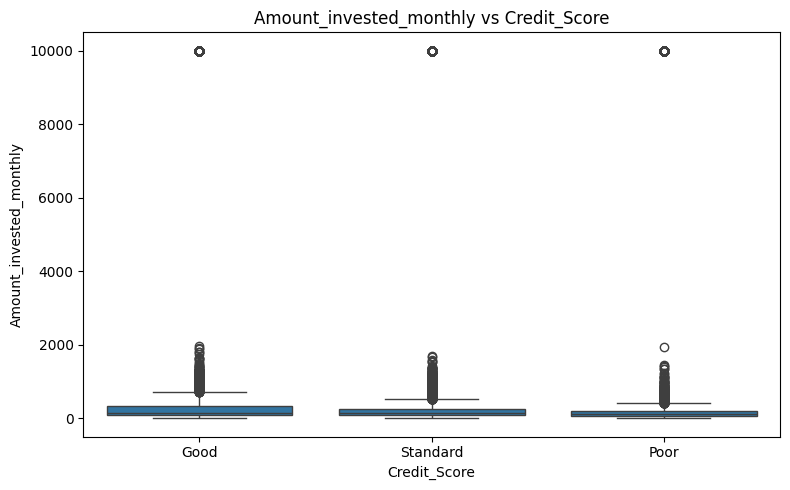

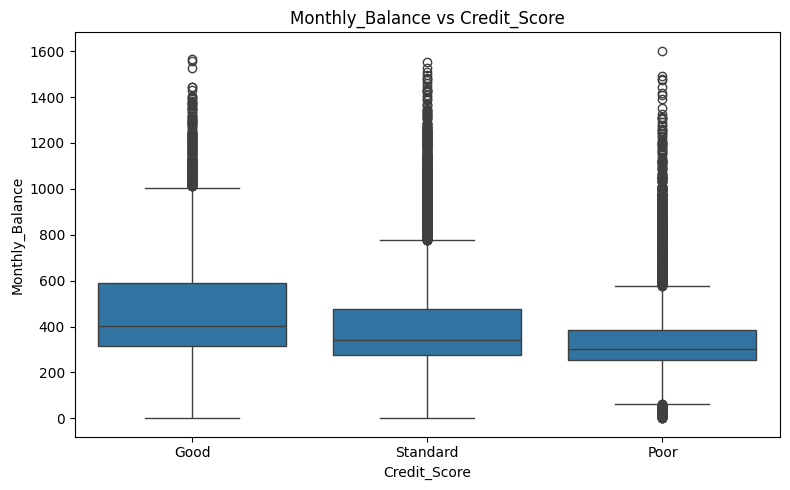

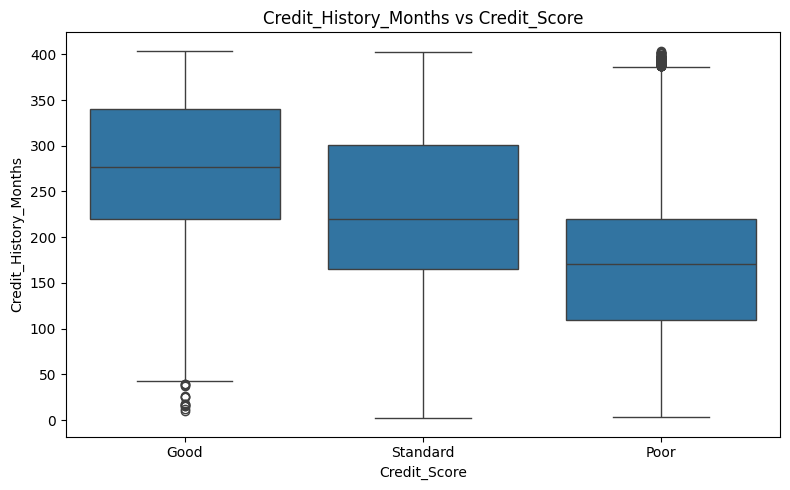

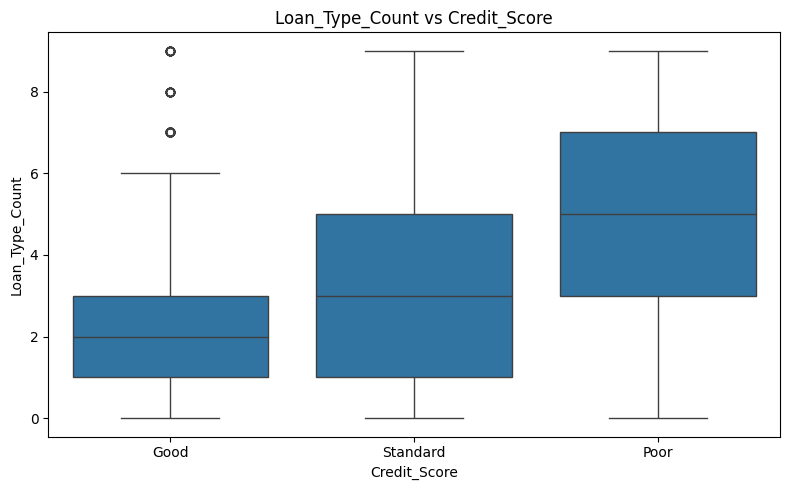

In [40]:
# numerical col vs target
for col in numCol:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Credit_Score', y=col, data=df, order=['Good', 'Standard', 'Poor'])
    plt.title(f'{col} vs Credit_Score')
    plt.tight_layout()
    plt.show()

* Outstanding_Debt: clear separation, Poor has much higher debt
* Interest_Rate: Poor > Standard > Good, very discriminative
* Delay_from_due_date: Poor has the longest delays
* Credit_History_Months: Good has the longest history, Poor the shortest
* Annual_Income: Good earns more on average
* Credit_Utilization_Ratio and Monthly_Inhand_Salary show less separation

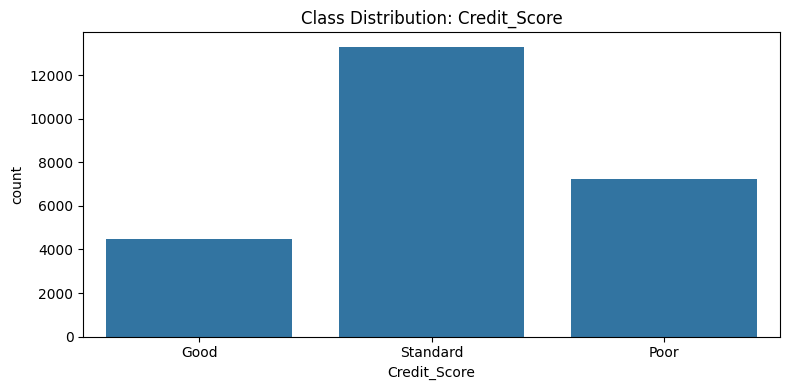

Credit_Score
Standard    13305
Poor         7231
Good         4464
Name: count, dtype: int64


In [41]:
# target column distribution
plt.figure(figsize=(8, 4))
sns.countplot(x='Credit_Score', data=df, order=['Good', 'Standard', 'Poor'])
plt.title('Class Distribution: Credit_Score')
plt.tight_layout()
plt.show()
print(df['Credit_Score'].value_counts())

The target is moderately imbalanced. Standard dominates at 53.2%, Poor at 28.9%, and Good at 17.9%. We need to handle this during modeling using class_weight

## **Correlation of Features & Target**

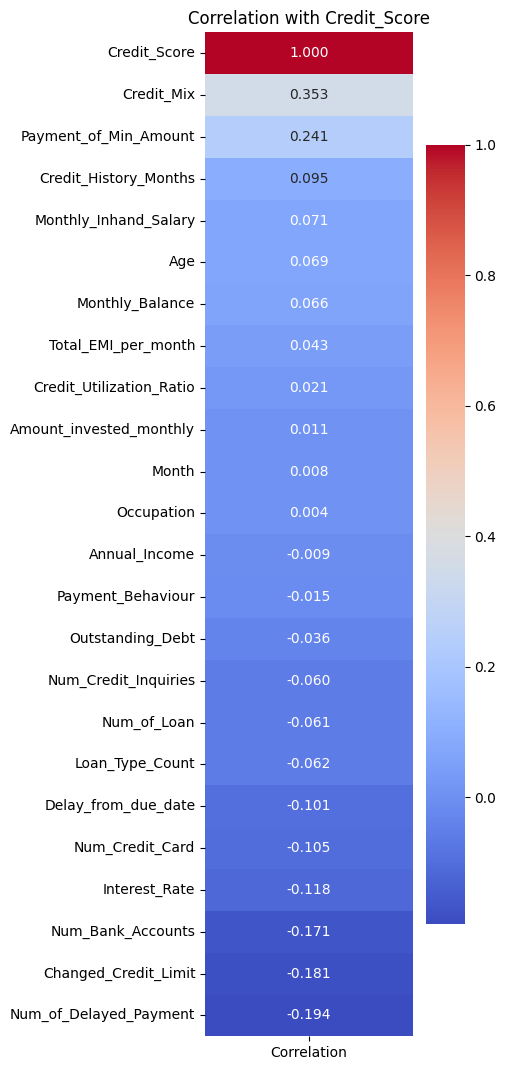

In [42]:
dfEncoded = df.copy()
for col in dfEncoded.select_dtypes(include=['object', 'category']).columns:
    dfEncoded[col], _ = pd.factorize(dfEncoded[col])
targetCorr = dfEncoded.corrwith(dfEncoded['Credit_Score']).sort_values(ascending=False)
targetCorrDf = targetCorr.to_frame(name='Correlation')
plt.figure(figsize=(5, len(targetCorrDf) * 0.45))
sns.heatmap(targetCorrDf, annot=True, cmap='coolwarm', cbar=True, fmt='.3f')
plt.title('Correlation with Credit_Score')
plt.tight_layout()
plt.show()

The highest correlating features are Credit_Mix, Payment_of_Min_Amount, and Credit_History_Months (positive), while Num_of_Delayed_Payment, Changed_Credit_Limit, and Num_Bank_Accounts have the strongest negative correlations

# **Modeling**

### Preprocessing Design

Previously, we decided to keep the outliers because they are valid extreme values, not data entry errors. While tree based models can handle this fine, we are also comparing Logistic Regression and SVM. These models are highly sensitive to feature scales and categorical encodings, so we need a proper preprocessing pipeline:

- Numerical Features: Processed using median imputation + RobustScaler. We chose RobustScaler instead of StandardScaler because it scales data using the median and IQR. This ensures the outliers we decided to keep don't distort or dominate the scaling.
- Credit_Mix: Encoded using OrdinalEncoder with an explicit order of ['Bad', 'Standard', 'Good']. Since this column has a natural ranking, setting this specific order allows the model to read it as a meaningful 0 > 1 > 2 progression instead of just sorting it alphabetically.
- Nominal Features (Month, Occupation, Payment_of_Min_Amount, Payment_Behaviour): Processed using OneHotEncoder. These columns don't have any inherent order, so one-hot encoding ensures the linear and distance-based models don't assume a fake hierarchy.

Although we already handled missing values earlier in the data cleaning step, keeping the SimpleImputer inside this final pipeline is intentional. This makes the pipeline object completely self-contained and safe to reuse later for deployment when predicting new, unseen data.

In [43]:
ordCol = ['Credit_Mix']
nomCol = [col for col in catCol if col not in ordCol]

numTransformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

ordTransformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[['Bad', 'Standard', 'Good']]))
])

nomTransformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessingPipeline = Pipeline(steps=[
    ('transformers', ColumnTransformer(transformers=[
        ('num', numTransformer, numCol),
        ('ord', ordTransformer, ordCol),
        ('nom', nomTransformer, nomCol)
    ], remainder='passthrough'))
])

In [44]:
# splitting data
X = df.drop(columns='Credit_Score')
y = df['Credit_Score']
xTrain, xTest, yTrain, yTest = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [45]:
xTrainProcessed = preprocessingPipeline.fit_transform(xTrain)
xTestProcessed = preprocessingPipeline.transform(xTest)
labelEncoder = LabelEncoder()
yTrainEncoded = labelEncoder.fit_transform(yTrain)
yTestEncoded = labelEncoder.transform(yTest)
print(f"Train: {xTrainProcessed.shape}, Test: {xTestProcessed.shape}")
print(f"Classes: {labelEncoder.classes_}")

Train: (20000, 50), Test: (5000, 50)
Classes: ['Good' 'Poor' 'Standard']


## **Baseline Comparison**

Since hyperparameter tuning takes a lot of time and computing power, we run several baseline models with default settings first to see which ones are actually worth tuning further. For the evaluation, standard accuracy won't work well because our target variable is imbalanced, and more importantly, different errors have different costs.

In credit risk, the worst mistake is missing a truly Poor customer, which means the model predicts they are Standard or Good when they are actually high-risk, because that leads directly to loan defaults. Misclassifying a Good customer, however, just results in an extra manual review. Therefore, we use Poor Recall as our primary metric to catch as many risky customers as possible, while keeping Macro F1 as a secondary check to make sure the model stays balanced across all classes.

In [46]:
baselineModels = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    'SVM': SVC(kernel='rbf', random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, eval_metric='mlogloss', random_state=42)
}

poorIndex = list(labelEncoder.classes_).index('Poor')
baselineResults = []

for name, model in baselineModels.items():
    model.fit(xTrainProcessed, yTrainEncoded)
    preds = model.predict(xTestProcessed)
    report = classification_report(yTestEncoded, preds, output_dict=True, zero_division=0)
    baselineResults.append({
        'Model': name,
        'Accuracy': report['accuracy'],
        'Macro F1': report['macro avg']['f1-score'],
        'Poor Recall': report[str(poorIndex)]['recall']
    })

baselineDf = pd.DataFrame(baselineResults).sort_values('Macro F1', ascending=False).reset_index(drop=True)
print(baselineDf.to_string(index=False))

              Model  Accuracy  Macro F1  Poor Recall
      Random Forest    0.7314  0.707202     0.692946
            XGBoost    0.7252  0.705154     0.704703
  Gradient Boosting    0.6962  0.672461     0.643154
                SVM    0.6504  0.645001     0.719225
Logistic Regression    0.6368  0.631858     0.689488
      Decision Tree    0.6308  0.600701     0.603734


Random Forest and XGBoost were selected for hyperparameter tuning because they provided the best balance across overall accuracy and Macro F1. While SVM achieved a slightly higher raw Poor recall, its poor overall accuracy and Macro F1 show that it was merely predicting Poor aggressively rather than properly separating the three classes.

## **Random Forest**

In [47]:
rfParamGrid = {
    'n_estimators': [100, 200],
    'max_depth': [15, 25, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}

In [48]:
rfSearch = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rfParamGrid,
    n_iter=5,
    cv=2,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

In [49]:
rfSearch.fit(xTrainProcessed, yTrainEncoded)

RandomizedSearchCV(cv=2, estimator=RandomForestClassifier(random_state=42),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'class_weight': ['balanced'],
                                        'max_depth': [15, 25, None],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [100, 200]},
                   random_state=42, scoring='f1_macro')

In [50]:
rfModel = rfSearch.best_estimator_
rfPreds = rfModel.predict(xTestProcessed)

In [51]:
print("Random Forest Results:")
print(classification_report(yTestEncoded, rfPreds, target_names=labelEncoder.classes_))

Random Forest Results:
              precision    recall  f1-score   support

        Good       0.60      0.72      0.65       893
        Poor       0.73      0.72      0.73      1446
    Standard       0.79      0.73      0.76      2661

    accuracy                           0.73      5000
   macro avg       0.70      0.72      0.71      5000
weighted avg       0.73      0.73      0.73      5000



## **XGBoost**

In [52]:
xgbParamGrid = {
    'n_estimators': [200, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [4, 6, 8, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

In [53]:
xgbSearch = RandomizedSearchCV(
    estimator=XGBClassifier(eval_metric='mlogloss', random_state=42),
    param_distributions=xgbParamGrid,
    n_iter=15,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

In [55]:
xgbSearch.fit(xTrainProcessed, yTrainEncoded)
xgbModel = xgbSearch.best_estimator_
xgbPreds = xgbModel.predict(xTestProcessed)

In [56]:
print("XBGoost Results:")
print(classification_report(yTestEncoded, xgbPreds, target_names=labelEncoder.classes_))

XBGoost Results:
              precision    recall  f1-score   support

        Good       0.67      0.62      0.64       893
        Poor       0.73      0.71      0.72      1446
    Standard       0.75      0.77      0.76      2661

    accuracy                           0.73      5000
   macro avg       0.71      0.70      0.71      5000
weighted avg       0.73      0.73      0.73      5000



## **Model Comparison**

In [57]:
rfReport = classification_report(yTestEncoded, rfPreds, output_dict=True)
xgbReport = classification_report(yTestEncoded, xgbPreds, output_dict=True)

rfAcc = rfReport['accuracy']
xgbAcc = xgbReport['accuracy']
rfMacroF1 = rfReport['macro avg']['f1-score']
xgbMacroF1 = xgbReport['macro avg']['f1-score']
rfPoorRecall = rfReport[str(poorIndex)]['recall']
xgbPoorRecall = xgbReport[str(poorIndex)]['recall']

print("Tuned Model Comparison")
print(f"{'Metric':<15}{'Random Forest':<15}{'XGBoost':<15}")
print(f"{'Accuracy':<15}{rfAcc:<15.4f}{xgbAcc:<15.4f}")
print(f"{'Macro F1':<15}{rfMacroF1:<15.4f}{xgbMacroF1:<15.4f}")
print(f"{'Poor Recall':<15}{rfPoorRecall:<15.4f}{xgbPoorRecall:<15.4f}")

# primary criterion: Poor-class recall. macro F1 only breaks a tie.
if rfPoorRecall != xgbPoorRecall:
    bestModel = rfModel if rfPoorRecall > xgbPoorRecall else xgbModel
    bestModelName = 'Random Forest' if rfPoorRecall > xgbPoorRecall else 'XGBoost'
else:
    bestModel = rfModel if rfMacroF1 >= xgbMacroF1 else xgbModel
    bestModelName = 'Random Forest' if rfMacroF1 >= xgbMacroF1 else 'XGBoost'

print(f"\nBest model for deployment: {bestModelName}")

Tuned Model Comparison
Metric         Random Forest  XGBoost        
Accuracy       0.7278         0.7286         
Macro F1       0.7117         0.7078         
Poor Recall    0.7248         0.7095         

Best model for deployment: Random Forest


We select the model with the higher Poor recall as our final deployment candidate instead of the one with the highest plain accuracy. A false negative, which happens when the model predicts Standard or Good for an actually Poor customer, is the most expensive mistake because it leads directly to loan defaults. Since a false positive only results in a cheap manual review, we prioritize catching as many high risk customers as possible even if it costs a bit of accuracy elsewhere.

## **Feature Importance**

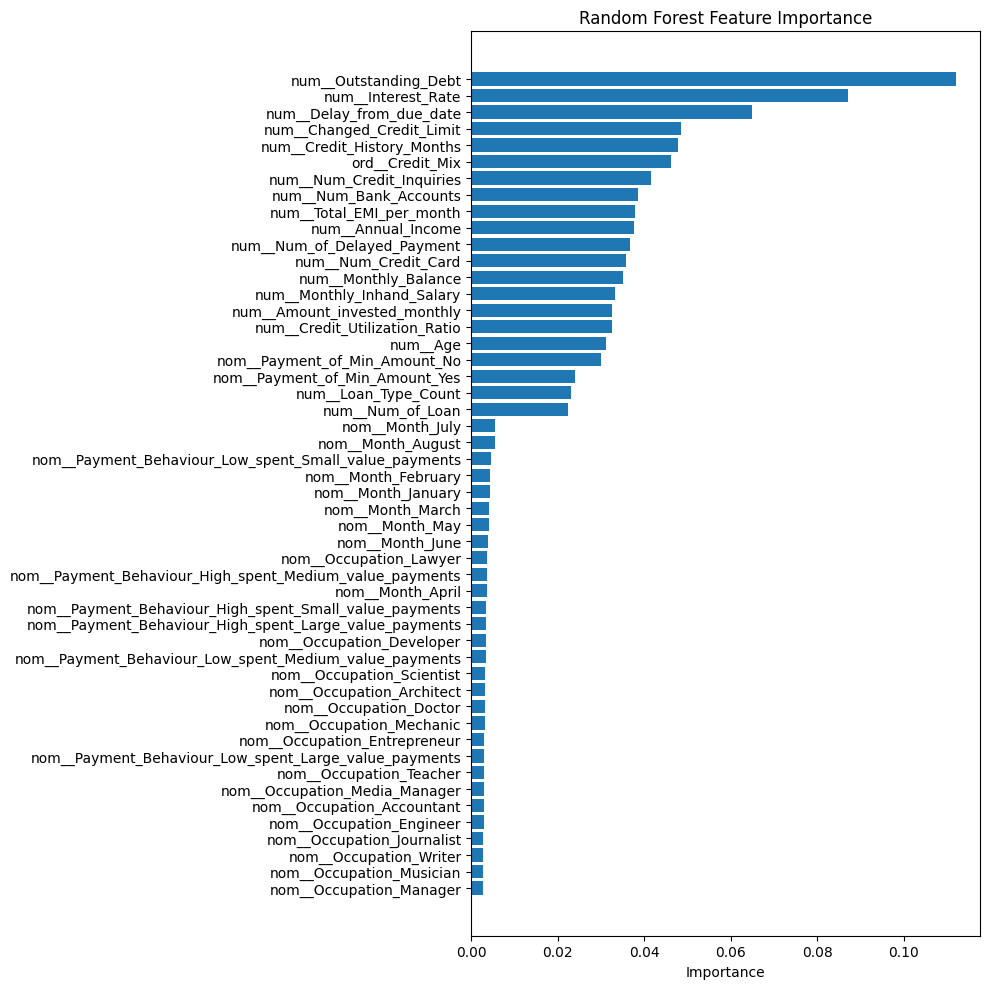

In [58]:
featureNames = preprocessingPipeline.named_steps['transformers'].get_feature_names_out()
importances = bestModel.feature_importances_
featureImportanceDf = pd.DataFrame({
    'Feature': featureNames,
    'Importance': importances
}).sort_values('Importance', ascending=True)
plt.figure(figsize=(10, 10))
plt.barh(featureImportanceDf['Feature'], featureImportanceDf['Importance'])
plt.title(f'{bestModelName} Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [59]:
# top features
topFeatures = featureImportanceDf.nlargest(8, 'Importance')
print("Top 8 Features:")
print(topFeatures.to_string(index=False))

Top 8 Features:
                   Feature  Importance
     num__Outstanding_Debt    0.111994
        num__Interest_Rate    0.086986
  num__Delay_from_due_date    0.064982
 num__Changed_Credit_Limit    0.048507
num__Credit_History_Months    0.047688
           ord__Credit_Mix    0.046200
 num__Num_Credit_Inquiries    0.041483
    num__Num_Bank_Accounts    0.038452


## **Exporting Pipeline**

In [60]:
fullPipeline = Pipeline(steps=[
    ('preprocessing', preprocessingPipeline),
    ('classifier', bestModel)
])
fullPipeline.fit(xTrain, yTrainEncoded)
joblib.dump(fullPipeline, 'final_model_pipeline.pkl')
joblib.dump(labelEncoder, 'label_encoder.pkl')
print(f"Best model exported: {bestModelName}")
print("Exported: final_model_pipeline.pkl")
print("Exported: label_encoder.pkl")

Best model exported: Random Forest
Exported: final_model_pipeline.pkl
Exported: label_encoder.pkl
